Section 1: Introduction and Model Selection

Situation: Modeling how a modern civic's suspension returns to normal ride height after driving over a speed bump, beginning at the top of the bump.

Governing Differential Equation:
    my''+cy'+ky=0

System of 1st Order Equations:
    y1 = y
    y2 = y'
    y1' = y2
    y' = (-cy2-ky1)/m

m = mass supported by wheel (kg)
c = damping coefficient (Ns/m)
k = spring constant (N/m)
y(t) = vertical distribution from spring equilibrium in (m)

Section 2: Parameter Research and Justification

Model: 2025 Honda Civic Sport 4dr Sedan
curb weight = 2934 lbs = 1331 kg (manufactorer based for this model)
m: 25% of car weight (approximating for support by each wheel) = 333 kg
k: spring constant = 18,000 N/m (rouhgly for Honda civic class)
c: damping coefficient = 2,500 Ns/m (roughly for moderate ride comfort)
    
Initial Conditions (top of bump):
y(0) = 0.08 m (curb roughly this tall)
y'(0) = 0 m/s (0 vertical velocity at top)
    
Final Equation:
333y'' + 2500y' + 18000y = 0 ; y(0) = 0.08 , y'(0) = 0
or
y1' = y2 , y2' = (-2500y2 - 18000y1) / 333

Edmunds. 2025 Honda Civic Sport Specs & Features
https://www.edmunds.com/honda/civic/2025/st-402036390/features-specs/?utm_source=chatgpt.com

Automobile-Catalog. 2025 Honda Civic Sport Sedan Weights & Dimensions
https://www.automobile-catalog.com/car/2025/3344510/honda_civic_sport_sedan.html?utm_source=chatgpt.com

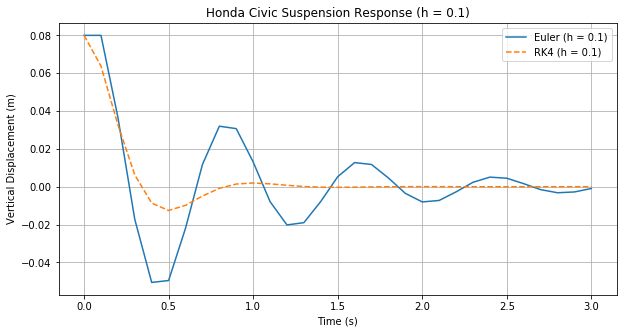

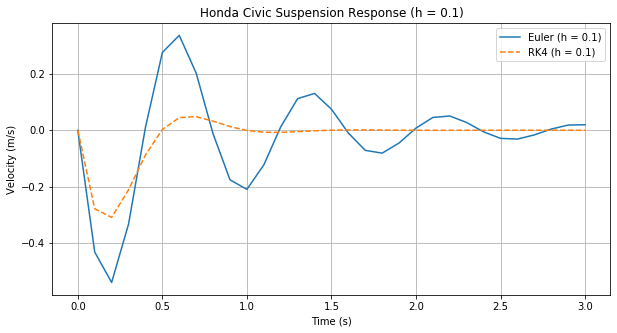

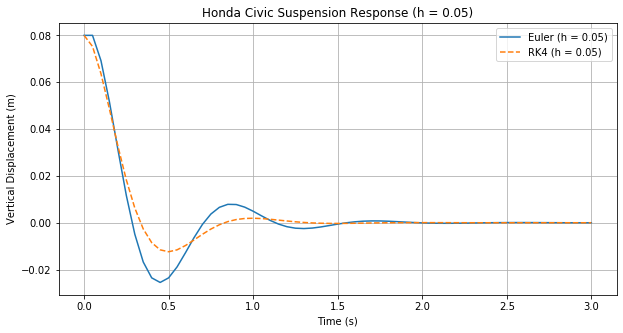

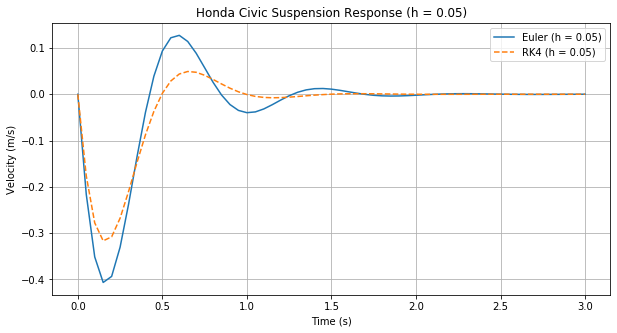

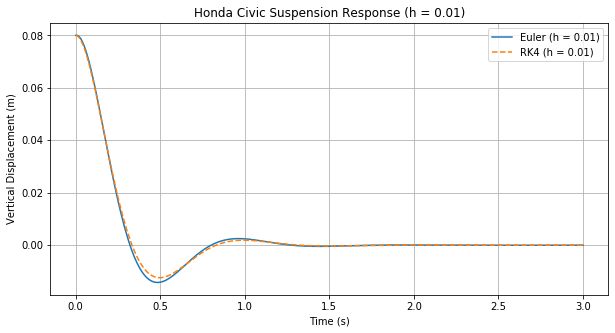

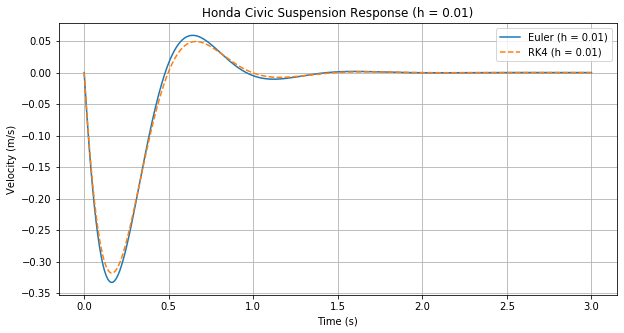

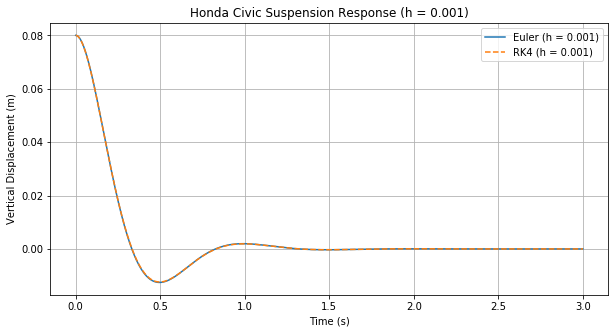

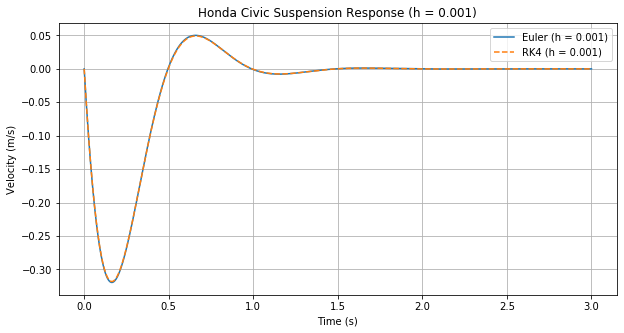

In [4]:
#Section 3: Numerical Methods Implementation
import numpy as np
import matplotlib.pyplot as plt

def f(t, y1, y2):
    """
    Returns derivatives at a time:
    Given: time(t), postition(y1), velocity(y2)
    """
    dy1dt = y2
    dy2dt = (-2500*y2 - 18000*y1 ) / 333
    return dy1dt, dy2dt

def euler_method(t0, tf, h, y1_0, y2_0):
    """
    Returns: arrays of time (t) and matching postitions (y1) and velocities (y2)
    Given: initial time(t0), final time(tf), step size(h), initial position(y1_0), initial velocity(y2_0)
    """
    #sets up arrays to return with right size
    n = int((tf - t0) / h)
    t = np.zeros(n + 1)
    y1 = np.zeros(n + 1)
    y2 = np.zeros(n + 1)
    #sets initial conditions
    t[0] = t0
    y1[0] = y1_0
    y2[0] = y2_0
    #goes step-by-step to calculate next points using linear approximation for step size between points
    for i in range(n):
        dy1dt, dy2dt = f(t[i], y1[i], y2[i])
        y1[i+1] = y1[i] + h * dy1dt
        y2[i+1] = y2[i] + h * dy2dt
        t[i+1] = t[i] + h
    return t, y1, y2

def rk4_method(t0, tf, h, y1_0, y2_0):
    """"
    Returns: arrays of time (t) and matching postitions (y1) and velocities (y2)
    Given: initial time(t0), final time(tf), step size(h), initial position(y1_0), initial velocity(y2_0)
    """
    #sets up arrays to return with right size
    n = int((tf - t0) / h)
    t = np.zeros(n + 1)
    y1 = np.zeros(n + 1)
    y2 = np.zeros(n + 1)
    #sets initial conditions
    t[0] = t0
    y1[0] = y1_0
    y2[0] = y2_0
    for i in range(n):
        # k1
        k1y1, k1y2 = f(t[i], y1[i], y2[i])
        # k2
        k2y1, k2y2 = f(t[i] + h/2, y1[i] + h*k1y1/2, y2[i] + h*k1y2/2)
        # k3
        k3y1, k3y2 = f(t[i] + h/2, y1[i] + h*k2y1/2, y2[i] + h*k2y2/2)
        # k4
        k4y1, k4y2 = f(t[i] + h, y1[i] + h*k3y1, y2[i] + h*k3y2)
        # Update values
        y1[i+1] = y1[i] + (h/6)*(k1y1 + 2*k2y1 + 2*k3y1 + k4y1)
        y2[i+1] = y2[i] + (h/6)*(k1y2 + 2*k2y2 + 2*k3y2 + k4y2)
        t[i+1] = t[i] + h
    return t, y1, y2

t0 = 0   #initial time
tf = 3   # simulate 3 seconds
y1_0 = 0.08   # displacement (m) max at top of bump
y2_0 = 0   # initial velocity
step_sizes = [0.1, 0.05, 0.01, 0.001]
#run both methods for all step sizes and graph both velocity and position vs. time for each
for h in step_sizes:
    t_e, y1_e, y2_e = euler_method(t0, tf, h, y1_0, y2_0)
    t_r, y1_r, y2_r = rk4_method(t0, tf, h, y1_0, y2_0)
    plt.figure(figsize=(10,5))
    plt.plot(t_e, y1_e, label=f'Euler (h = {h})')
    plt.plot(t_r, y1_r, label=f'RK4 (h = {h})', linestyle="--")
    plt.title(f"Honda Civic Suspension Displacement (h = {h})")
    plt.xlabel("Time (s)")
    plt.ylabel("Vertical Displacement (m)")
    plt.grid(True)
    plt.legend()
    plt.show()
    plt.figure(figsize=(10,5))
    plt.plot(t_e, y2_e, label=f'Euler (h = {h})')
    plt.plot(t_r, y2_r, label=f'RK4 (h = {h})', linestyle="--")
    plt.title(f"Honda Civic Suspension Velocity (h = {h})")
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (m/s)")
    plt.grid(True)
    plt.legend()
    plt.show()

The Runge-Kutta method seems more consistent at larger step sizes when compared to the small step sizes. The shape for both position and velocity curve remains relatively the same for all step sizes. However, euler's method is more jumpy and less consistent for larger step sizes. However, with smaller step sizes, both curves end up smooth and essentially the same.

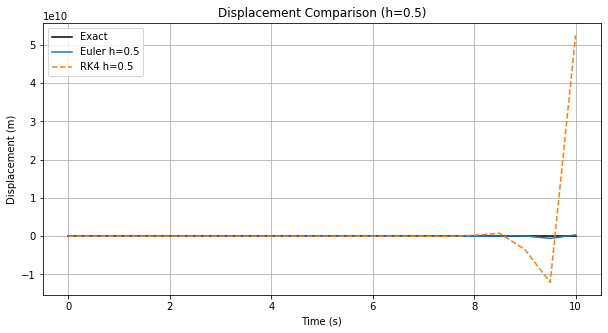

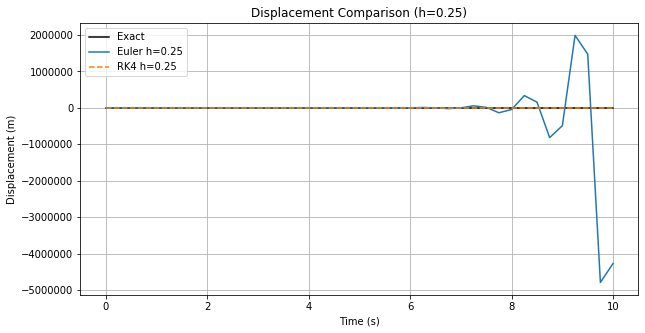

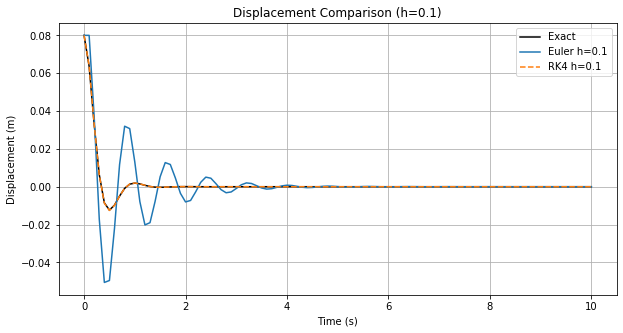

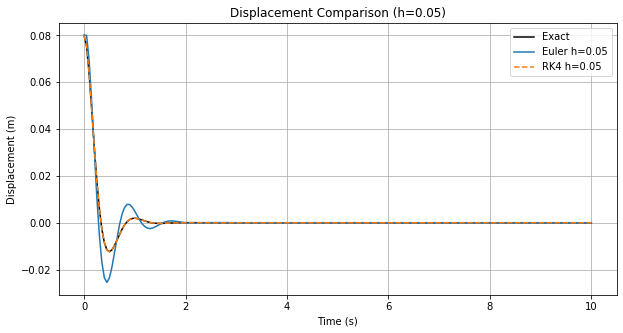

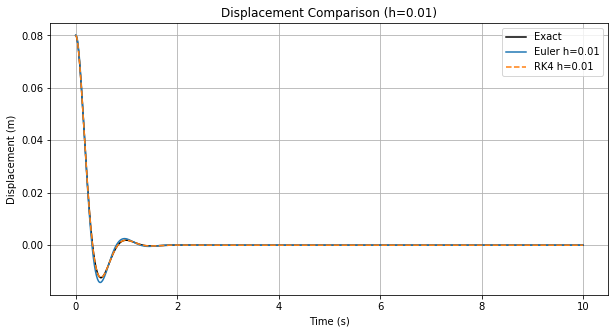

Max Step Size for Euler's method = (approximately) 0.27 
Max Step Size for Runge Kutta method = (approximately) 0.4


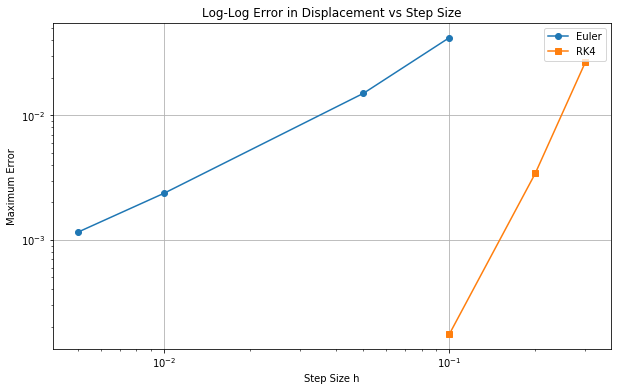

Euler slope = 1.188252203750637
RK4 slope = 4.549762989428385


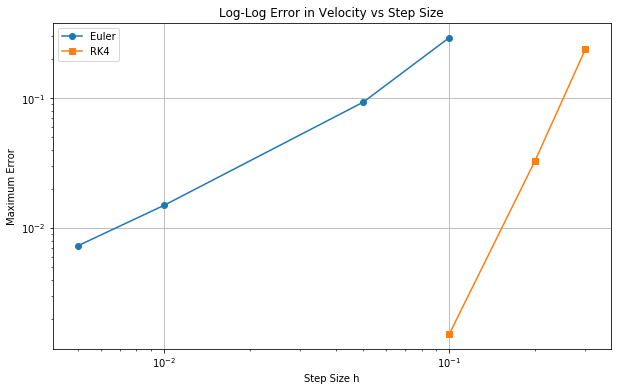

Euler slope = 1.211963882068179
RK4 slope = 4.585197541585748


In [29]:
# EXACT ANALYTICAL SOLUTION
#y(t)=e^(−3.7545t)(0.08cos(6.3215t)+0.0475sin(6.3215t))     claude used to solve
#y′(t)=y′(t)=e^(−3.7545t)[−3.7545(0.08cos(6.3215t)+0.0475sin(6.3215t))+0.3004cos(6.3215t)−0.5058sin(6.3215t)]    claude used
def exact_solution(t):
    alpha = 3.7538
    beta  = 6.3215
    C1, C2 = 0.08, 0.04752
    y = np.exp(-alpha*t) * (C1*np.cos(beta*t) + C2*np.sin(beta*t))
    v = np.exp(-alpha*t) * ((-alpha)*(C1*np.cos(beta*t) + C2*np.sin(beta*t)) + beta*(-C1*np.sin(beta*t) + C2*np.cos(beta*t)))
    return y, v

#Analyzing different step sizes
test_steps = [0.5, 0.25, 0.1, 0.05, 0.01]
for h in test_steps:
    #solve with Euler's, RK4, and exact
    t_e, y_e, v_e = euler_method(t0, 10, h, y1_0, y2_0)
    t_r, y_r, v_r = rk4_method(t0, 10, h, y1_0, y2_0)
    y_exact, v_exact = exact_solution(t_e)
    plt.figure(figsize=(10,5))
    plt.plot(t_e, y_exact, 'k', label='Exact')
    plt.plot(t_e, y_e, label=f'Euler h={h}')
    plt.plot(t_r, y_r, '--', label=f'RK4 h={h}')
    plt.title(f"Displacement Comparison (h={h})")
    plt.xlabel("Time (s)")
    plt.ylabel("Displacement (m)")
    plt.grid(True)
    plt.legend()
    plt.show()
print("Max Step Size for Euler's method = (approximately) 0.27 \nMax Step Size for Runge Kutta method = (approximately) 0.4")

#Error Analysis
h_vals_euler = np.array([0.1, 0.05, 0.01, 0.005])  #Cluade used to find h values that would work for both methods
h_vals_rk4 = np.array([0.3, 0.2, 0.1])
#set up arrays
euler_error_y = []
euler_error_v = []
rk4_error_y = []
rk4_error_v = []
for h in h_vals_euler:
    #find Euler error
    t_e, y_e, v_e = euler_method(t0, tf, h, y1_0, y2_0)
    y_exact, v_exact = exact_solution(t_e)
    err_y = np.max(np.abs(y_e - y_exact))
    euler_error_y.append(err_y)
    err_v = np.max(np.abs(v_e - v_exact))
    euler_error_v.append(err_v)
for h in h_vals_rk4:
    #find RK4 error
    t_r, y_r, v_r = rk4_method(t0, tf, h, y1_0, y2_0)
    y_exact, v_exact = exact_solution(t_r)
    err_y = np.max(np.abs(y_r - y_exact))
    rk4_error_y.append(err_y)
    err_v = np.max(np.abs(v_r - v_exact))
    rk4_error_v.append(err_v)
#putting errors in arrays
euler_error_y = np.array(euler_error_y)
euler_error_v = np.array(euler_error_v)
rk4_error_y = np.array(rk4_error_y)
rk4_error_v = np.array(rk4_error_v)

#Log-log error plot for position
plt.figure(figsize=(10,6))
plt.loglog(h_vals_euler, euler_error_y, 'o-', label='Euler')
plt.loglog(h_vals_rk4, rk4_error_y, 's-', label='RK4')
plt.title("Log-Log Error in Displacement vs Step Size")
plt.xlabel("Step Size h")
plt.ylabel("Maximum Error")
plt.grid(True)
plt.legend()
plt.show()
#Convergence slopes for position
slope_euler = np.polyfit(np.log(h_vals_euler), np.log(euler_error_y), 1)[0]
slope_rk4 = np.polyfit(np.log(h_vals_rk4), np.log(rk4_error_y), 1)[0]
print("Euler slope =", slope_euler)
print("RK4 slope =", slope_rk4)

#Log-log error plot for velocity
plt.figure(figsize=(10,6))
plt.loglog(h_vals_euler, euler_error_v, 'o-', label='Euler')
plt.loglog(h_vals_rk4, rk4_error_v, 's-', label='RK4')
plt.title("Log-Log Error in Velocity vs Step Size")
plt.xlabel("Step Size h")
plt.ylabel("Maximum Error")
plt.grid(True)
plt.legend()
plt.show()
#Convergence slopes for position
slope_euler = np.polyfit(np.log(h_vals_euler), np.log(euler_error_v), 1)[0]
slope_rk4 = np.polyfit(np.log(h_vals_rk4), np.log(rk4_error_v), 1)[0]
print("Euler slope =", slope_euler)
print("RK4 slope =", slope_rk4)

Numerical instabilities in this situation do lead to non-physical results. As a damped system, the displacement should converge to 0. However, with too large of step sizes, Euler's method and Runge Kutta diverge away from this (as shown in h = 0.5, 0.25). This numerical instability causes a result that does not align with what we know should happen for the damped system. However, when the system is numerically stable (h = 0.1, 0.01), it does make physical sense as the energy is taken out of the system from damping and the displacement and velocity converges towards 0.

Conclusions:
For modeling the Civic's suspension system, the Runge Kutta method significantly outperformed Euler's method. At the same step sizes, Runge Kutta had errors that were much smaller than Euler's, and it maintained a larger stability region, being able to go to much larger step sizes and remaining stable.
Runge Kutta is also more computationally efficient for a target step size because although it takes more computations per step, it can use a much larger step size and have similar accuracy to Euler's method. For example, Runge Kutta at h = 0.05 is more accurate than Euler's at h = 0.01, making it more efficient at the respective step sizes and more accurate.
Because of this, I would practically recommend Runge Kutta at h = 0.05 because it is both relatively computationally efficient and accurate.
I learned that which system you use depends on the problem. For example, this damped system required numerical stability, and Runge Kutta got us that at larger step sizes allowing it to be more preferable.